# Logistic Regression from Scratch

## Objective
Implement binary Logistic Regression from scratch using NumPy.

To be implemented:
1. Sigmoid
2. Linear score
3. Predicted probabilities
4. Cost function
5. Gradients
6. One gradient-descent update
7. Complete gradient descent
8. Class prediction
9. Accuracy
10. Decision boundary

**Rules:** Use NumPy. Do not use `sklearn.linear_model.LogisticRegression`. Complete only cells marked **YOUR CODE HERE**.

## 1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
## New dataset value
from sklearn.datasets import make_blobs

## 2. Load the Dataset

`X` contains two features and `y` contains binary class labels.

Inspect the shapes before continuing.

In [3]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12, 2)
y shape: (12,)


In [ ]:
## Changing the X 

X, y = make_blobs(
    n_samples=500,
    centers=2,
    n_features=2,
    random_state=42
)

## 3. Visualize the Dataset

Plot Class 0 and Class 1 using different markers or colours.

- Feature 1 → x-axis
- Feature 2 → y-axis

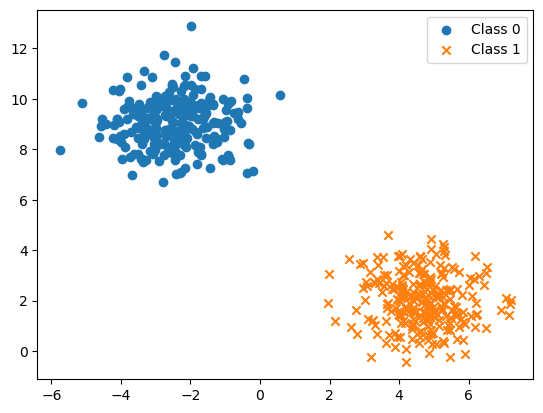

In [31]:
# Plot the two classes separately
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", label="Class 1")
plt.legend()


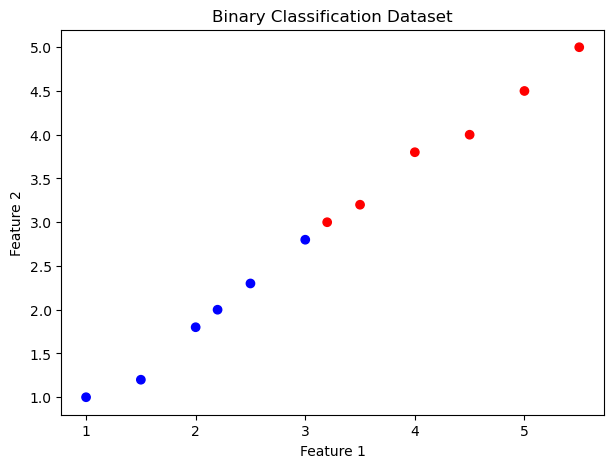

In [5]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

## 4. Logistic Regression Model

The model first calculates

$$
z = Xw+b
$$

and then

$$
\hat y = \sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If `X.shape = (m,n)` and `w.shape = (n,)`, then `X @ w` has shape `(m,)`.

## 5. Step 1 — Implement Sigmoid

### Task
Complete `sigmoid(z)`.

Use `np.exp()`. Your function should work for both a scalar and a NumPy array.

In [32]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [33]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## 6. Step 2 — Compute the Linear Score

Implement

`z = X @ w + b`

### Hint
Use the `@` operator for matrix-vector multiplication.

In [34]:
def compute_z(X, w, b):
    return X @ w + b


In [35]:
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

## 7. Step 3 — Compute Predicted Probabilities

The predicted probability is

$$
\hat y = \sigma(Xw+b)
$$

### Task
Implement `predict_probability()` using the functions you have already written.

In [36]:
def predict_probability(X, w, b):
    z = compute_z(X, w, b)
    return sigmoid(z)


In [37]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.

## 8. Step 4 — Implement the Cost Function

For binary Logistic Regression,

$$
J =
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log(\hat y^{(i)})
+
(1-y^{(i)})\log(1-\hat y^{(i)})
\right]
$$

Use `np.clip()` to avoid taking `log(0)`.

### Hint
```python
epsilon = 1e-15
probabilities = np.clip(probabilities, epsilon, 1-epsilon)
```

In [39]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    probabilities = predict_probability(X, w, b)

    # Small epsilon prevents log(0)
    epsilon = 1e-15
    probabilities = np.clip(probabilities, epsilon, 1 - epsilon)

    cost = -(1 / m) * np.sum(
        y * np.log(probabilities) +
        (1 - y) * np.log(1 - probabilities)
    )

    return cost


In [40]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

Initial cost: 0.6931471805599454


## 9. Step 5 — Compute the Gradients

The gradients are

$$
dw = \frac{1}{m}X^T(\hat y-y)
$$

$$
db = \frac{1}{m}\sum(\hat y-y)
$$

### Shape check

If

```text
X.shape = (m,n)
w.shape = (n,)
y.shape = (m,)
```

then

```text
X.T.shape = (n,m)
y_hat-y   = (m,)
dw        = (n,)
```

Do not use a loop over training examples. Rather, use broadcasting.

In [41]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]

    probabilities = predict_probability(X, w, b)
    error = probabilities - y

    dw = (1 / m) * (X.T @ error)
    db = (1 / m) * np.sum(error)

    return dw, db


In [42]:
dw, db = compute_gradients(X, y, w, b)

print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

dw: [-1.79131934  1.75156941]
dw shape: (2,)
db: 0.0


## 10. Step 6 — Implement One Gradient-Descent Update

Use

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

### Task
Compute the gradients, update `w` and `b`, and return them.

In [43]:
def gradient_descent_step(X, y, w, b, learning_rate):
    dw, db = compute_gradients(X, y, w, b)

    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b


## 11. Step 7 — Implement Complete Gradient Descent

For each iteration:
1. Compute probabilities.
2. Compute cost.
3. Compute gradients.
4. Update parameters.
5. Store the cost.

In [44]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w = np.zeros(X.shape[1])
    b = 0.0

    cost_history = []

    for i in range(num_iterations):

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        w, b = gradient_descent_step(
            X, y, w, b, learning_rate
        )

    return w, b, cost_history


## 12. Train the Model

Use learning rate `0.1` and `1000` iterations.

In [45]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [ 1.88202374 -0.50717884]
Final bias: 0.2532725020827231
Final cost: 0.0013958277896824057


## 13. Plot the Cost

Plot iteration number against cost.

### Expected observation
The cost should generally decrease during training.

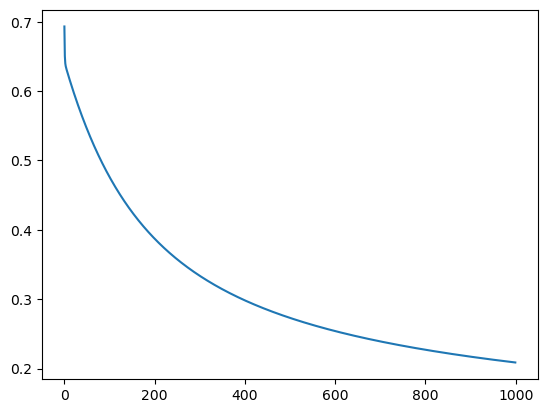

In [19]:
plt.plot(cost_history)


## 14. Step 8 — Convert Probabilities into Class Predictions

Use the rule

$$
\hat y =
\begin{cases}
1 & \text{if probability} \geq 0.5\\
0 & \text{otherwise}
\end{cases}
$$

### Hint
```python
(probabilities >= threshold).astype(int)
```

In [46]:
def predict(X, w, b, threshold=0.5):
    probabilities = predict_probability(X, w, b)
    return (probabilities >= threshold).astype(int)


In [47]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0
 0 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1
 0 1 1 0 1 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 0
 0 1 0 1 0 1 0 1 1 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 0 1
 0 1 1 1 1 1 0 1 0 0 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0
 0 0 1 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0
 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0
 1 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1
 0 0 1 0 1 0 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0
 1 1 0 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 1
 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1 1 1 0 0 0 1 0 1 0 0 1 1 1
 0 0 0 1 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 0 1 1 0
 1 1 1 0 1 1

## 15. Step 9 — Calculate Accuracy

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

### Task
Implement `accuracy()` using NumPy.

In [48]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


In [49]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 1.0


## 16. Step 10 — Visualize the Decision Boundary

For two features, the decision boundary is

$$
w_1x_1+w_2x_2+b=0
$$

Therefore,

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

### Task
Plot the two classes and the learned decision boundary.

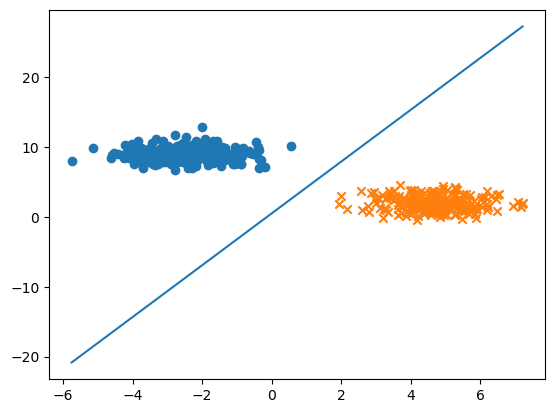

In [50]:
# Plot the data
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", label="Class 1")

# Decision boundary: w1*x1 + w2*x2 + b = 0
x1_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2_values = -(w[0] * x1_values + b) / w[1]

plt.plot(x1_values, x2_values, label="Decision Boundary")


# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?

In [25]:
learning_rates = [0.001, 0.1, 1.0]

# Train the model for each learning rate and compare the final cost and accuracy.
for lr in learning_rates:
    w_lr, b_lr, cost_history_lr = train_logistic_regression(
        X, y, learning_rate=lr, num_iterations=1000
    )
    y_pred_lr = predict(X, w_lr, b_lr)
    print(
        f"Learning rate = {lr}: "
        f"Final cost = {cost_history_lr[-1]:.6f}, "
        f"Accuracy = {accuracy(y, y_pred_lr):.4f}"
    )


Learning rate = 0.001: Final cost = 0.619932, Accuracy = 0.5000
Learning rate = 0.1: Final cost = 0.208888, Accuracy = 0.9167
Learning rate = 1.0: Final cost = 0.100108, Accuracy = 1.0000


# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?

In [26]:
thresholds = [0.3, 0.5, 0.7]

# Compare predictions and accuracy at different classification thresholds.
probabilities = predict_probability(X, w, b)

for threshold in thresholds:
    y_pred_threshold = predict(X, w, b, threshold=threshold)
    print(
        f"Threshold = {threshold}: "
        f"Accuracy = {accuracy(y, y_pred_threshold):.4f}, "
        f"Predicted Class 1 = {np.sum(y_pred_threshold)}"
    )


Threshold = 0.3: Accuracy = 0.9167, Predicted Class 1 = 7
Threshold = 0.5: Accuracy = 0.9167, Predicted Class 1 = 7
Threshold = 0.7: Accuracy = 0.9167, Predicted Class 1 = 5


**Important:** Use vectorized NumPy operations wherever possible instead of loops.